# Restoring the trained goal proposers

In [1]:
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import jax
import matplotlib.pyplot as plt
import numpy as np

from agents.goal_proposer import make_goal_proposer_config, restore_gc_flow_goal_proposer


/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [3]:
ENV_NAME = 'humanoidmaze-giant-navigate-v0'
ENV_DATASET_PATH = '../../scratch/data/humanoidmaze-giant-navigate-v0/humanoidmaze-giant-navigate-100m-v0/humanoidmaze-giant-navigate-v0-003.npz'

base_config = dict(
    observations_key='observations',
    goal_key='actor_goals',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    flow_steps=10,
    seed=0,
    discount=0.995,
    backup_horizon=25,
)

proposer_specs = {
    'unconditioned_h100': dict(observation_conditioned=False, horizon_conditioned=False),
    'observation_h100': dict(observation_conditioned=True, horizon_conditioned=False),
    'observation_horizon_h1_100': dict(observation_conditioned=True, horizon_conditioned=True),
}

example_batch = dict(
    observations=np.zeros((1, 2), dtype=np.float32),
    actor_goals=np.zeros((1, 2), dtype=np.float32),
    low_actor_goals=np.zeros((1, 2), dtype=np.float32),
    horizons=np.full((1, 1), 100.0, dtype=np.float32),
)


In [4]:
with np.load(ENV_DATASET_PATH) as env_dataset:
    env_xy = env_dataset['observations'][:, :2]
    all_cell_points = np.unique(np.floor(env_xy), axis=0).astype(np.float32)

print(f'{ENV_NAME}: {len(all_cell_points):,} occupied cells')
all_cell_points[:5]


humanoidmaze-giant-navigate-v0: 1,376 occupied cells


array([[-2., -2.],
       [-2., -1.],
       [-2.,  0.],
       [-2.,  1.],
       [-2.,  2.]], dtype=float32)

In [5]:
goal_proposers = {}
checkpoint_steps = {}

for name, spec in proposer_specs.items():
    config = make_goal_proposer_config(name, base_config=base_config, **spec)
    agent, step = restore_gc_flow_goal_proposer(name, example_batch, config)
    goal_proposers[name] = agent
    checkpoint_steps[name] = step
    print(f'{name}: restored checkpoint {step:,}')


Restored from checkpoints/gc_flow_goal_proposer/unconditioned_h100/params_3000000.pkl
unconditioned_h100: restored checkpoint 3,000,000
Restored from checkpoints/gc_flow_goal_proposer/observation_h100/params_3000000.pkl
observation_h100: restored checkpoint 3,000,000
Restored from checkpoints/gc_flow_goal_proposer/observation_horizon_h1_100/params_3000000.pkl
observation_horizon_h1_100: restored checkpoint 3,000,000


In [6]:
conditioning_observation = np.array([0.0, 0.0], dtype=np.float32)
conditioning_horizon = 100.0
num_plot_samples = 128

rng = jax.random.PRNGKey(0)
samples = {}
for name, agent in goal_proposers.items():
    rng, sample_rng = jax.random.split(rng)

    if agent.config['observation_conditioned']:
        observations = np.repeat(conditioning_observation[None], num_plot_samples, axis=0)
    else:
        observations = None

    horizons = None
    if agent.config['horizon_conditioned']:
        horizons = np.full((num_plot_samples, 1), conditioning_horizon, dtype=np.float32)

    if observations is None:
        sample = agent.sample_actions(num_samples=num_plot_samples, horizons=horizons, seed=sample_rng)
    else:
        sample = agent.sample_actions(observations=observations, horizons=horizons, seed=sample_rng)

    samples[name] = np.asarray(sample)

{k: v.shape for k, v in samples.items()}


{'unconditioned_h100': (128, 2),
 'observation_h100': (128, 2),
 'observation_horizon_h1_100': (128, 2)}

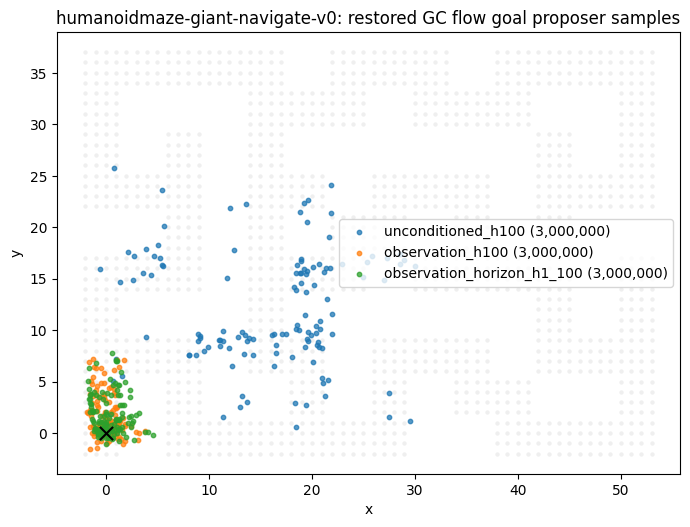

In [7]:
def sample_points(sample):
    points = np.asarray(sample)
    if points.ndim == 1:
        points = points[None, :]
    return points[:, :2]

fig, ax = plt.subplots(figsize=(7, 7))
colors = {
    'unconditioned_h100': 'tab:blue',
    'observation_h100': 'tab:orange',
    'observation_horizon_h1_100': 'tab:green',
}

ax.scatter(
    all_cell_points[:, 0],
    all_cell_points[:, 1],
    s=10,
    alpha=0.12,
    color='gray',
    linewidths=0,
    # label='occupied cells',
)

for name, sample in samples.items():
    points = sample_points(sample)
    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=10,
        alpha=0.75,
        color=colors[name],
        label=f'{name} ({checkpoint_steps[name]:,})',
    )
    label_xy = points[0]
    # ax.annotate(name, xy=label_xy, xytext=(6, 6), textcoords='offset points', fontsize=9)

ax.scatter(
    conditioning_observation[0],
    conditioning_observation[1],
    marker='x',
    s=90,
    color='black',
    # label='conditioning observation',
)
# ax.axhline(0, color='0.85', linewidth=1)
# ax.axvline(0, color='0.85', linewidth=1)
ax.set_title(f'{ENV_NAME}: restored GC flow goal proposer samples')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='best')
fig.tight_layout()


In [ ]:
# Continue each restored proposer for 2M more steps with the same specs/checkpoint cadence as 09.
# This continues the latest checkpoints, so the current 3,000,000-step agents will save through 5,000,000.
%run train_restored_goal_proposers.py --additional-steps 2000000 --save-interval 250000
